In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.incertidumbres import (
    graficar_imagen,
    crear_dataframe_incertidumbre,
    plot_incertidumbres,
    plot_combinado
)
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
import pickle
import pandas as pd
import tensorflow as tf

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
model_name = "ResNet152V2" #"MobileNetV3Large" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"../models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv-birds-song/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
with open(f'../models/label_encoder_{model_name}.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

In [26]:
preprocessor = ImagePreprocessor(label_encoder=label_encoder)
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")
data.head()

,label,image_path
0,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/121142_13.jpeg
1,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/511703_5.jpeg
2,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/461011_0.jpeg
3,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/621780_9.jpeg
4,Acropternis orthonyx,../src/data/images_test/images_spectograms/Acropternis orthonyx/428484_0.jpeg


In [5]:
sp_metrics = pd.read_csv("../models/metrics_resnet.csv")

In [6]:
sp = data[data["label"] == "Lathrotriccus euleri"]
sp.sample(6)

,label,image_path
14713,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_5.jpeg
14681,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/102718_1.jpeg
14697,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/72564_9.jpeg
14663,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/586950_4.jpeg
14670,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/427525_13.jpeg
14692,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/272813_0.jpeg


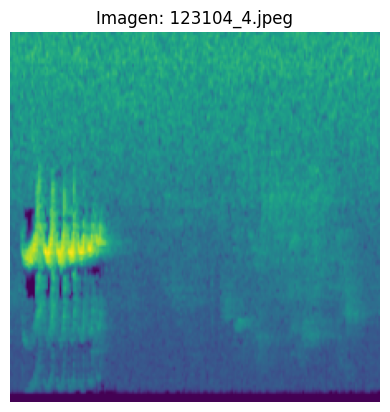

In [7]:
graficar_imagen(sp['image_path'].iloc[32])

# **Volatinia jacarina**

In [8]:
sp = data[data["label"] == "Volatinia jacarina"]
muestra = sp[sp['image_path'].str.contains('146774_0.jpeg')]
muestra

,label,image_path
31431,Volatinia jacarina,../src/data/images_test/images_spectograms/Volatinia jacarina/146774_0.jpeg


In [9]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Volatinia jacarina)


2025-08-24 17:34:42.983241: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.61s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Volatinia jacarina,651,651,651,0.02,1,1,6.44
1,Volatinia jacarina,651,651,114,0.01,1,0,6.44
2,Volatinia jacarina,651,651,651,0.01,1,1,6.44
3,Volatinia jacarina,651,651,651,0.01,1,1,6.44
4,Volatinia jacarina,651,651,651,0.01,1,1,6.44


In [10]:
Volatinia_jacarina = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [11]:
Volatinia_jacarina

,prediccion_mc,proportion
0,651,0.85
1,114,0.05
2,298,0.05
3,641,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


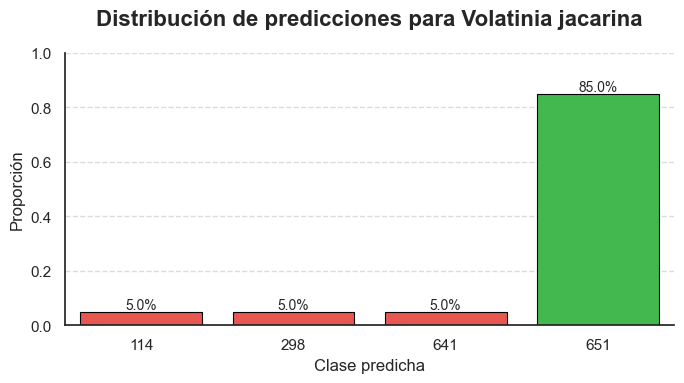

In [12]:
plot_incertidumbres(Volatinia_jacarina, 651, "Volatinia jacarina")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


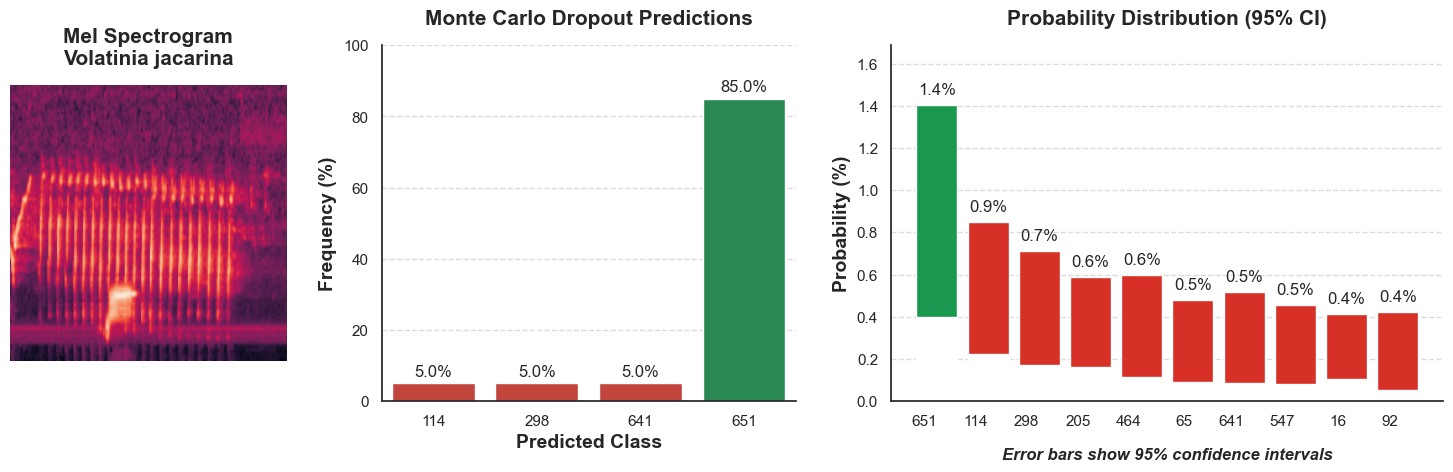

In [13]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Volatinia_jacarina,
    label=651,
    titulo_especie="Volatinia jacarina",
    predicted_probabilities=resultados["Volatinia jacarina"]["predicted_probabilities"],
    etiqueta_real=resultados["Volatinia jacarina"]["clase_real"][0]
)

In [14]:
labels_frecuencia = [17, 65, 97, 114, 205, 298, 464, 554, 641, 651]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 17: Arremon aurantiirostris
2 - 65: Cantorchilus leucotis
3 - 97: Chlorospingus canigularis
4 - 114: Coereba flaveola
5 - 205: Euphonia chrysopasta
6 - 298: Lanio fulvus
7 - 464: Pseudopipra pipra
8 - 554: Stelgidopteryx ruficollis
9 - 641: Vireo chivi
10 - 651: Volatinia jacarina


# **Legatus leucophaius**

In [15]:
sp = data[data["label"] == "Legatus leucophaius"]
muestra = sp[sp['image_path'].str.contains('275478_4.jpeg')]
muestra

,label,image_path
14744,Legatus leucophaius,../src/data/images_test/images_spectograms/Legatus leucophaius/275478_4.jpeg


In [16]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Legatus leucophaius)


2025-08-24 17:34:51.808438: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.51s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Legatus leucophaius,301,301,344,0.01,1,0,6.46
1,Legatus leucophaius,301,301,301,0.01,1,1,6.46
2,Legatus leucophaius,301,301,301,0.01,1,1,6.46
3,Legatus leucophaius,301,301,344,0.01,1,0,6.46
4,Legatus leucophaius,301,301,92,0.00,1,0,6.46


In [17]:
Legatus_leucophaius = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [18]:
Legatus_leucophaius

,prediccion_mc,proportion
0,301,0.55
1,344,0.10
2,92,0.05
3,99,0.05
4,261,0.05
5,63,0.05
6,128,0.05
7,536,0.05
8,213,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


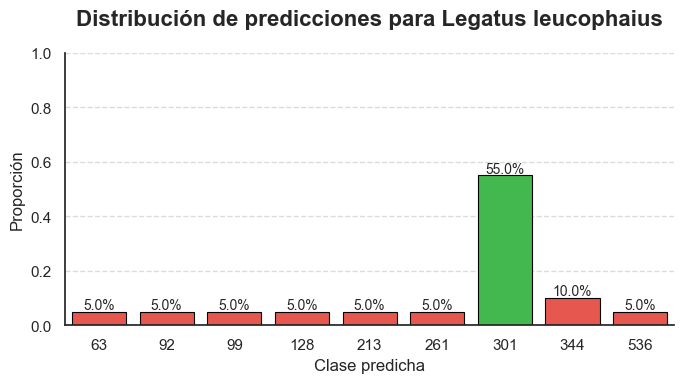

In [19]:
plot_incertidumbres(Legatus_leucophaius, 301, "Legatus leucophaius")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


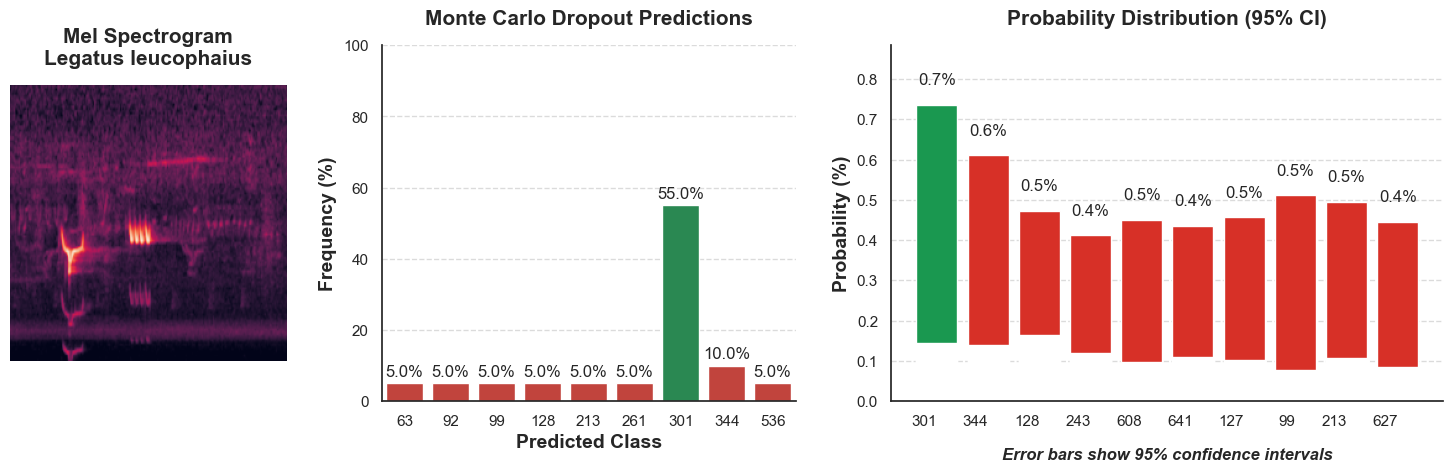

In [20]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[1],
    especie_df=Legatus_leucophaius,
    label=301,
    titulo_especie="Legatus leucophaius",
    predicted_probabilities=resultados["Legatus leucophaius"]["predicted_probabilities"],
    etiqueta_real=resultados["Legatus leucophaius"]["clase_real"][0]
)

In [21]:
labels_frecuencia = [127, 128, 204, 214, 243, 301, 344, 608, 641, 654]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 127: Contopus sordidulus
2 - 128: Contopus virens
3 - 204: Euphonia chlorotica
4 - 214: Euphonia xanthogaster
5 - 243: Grallaricula flavirostris
6 - 301: Legatus leucophaius
7 - 344: Myadestes ralloides
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 654: Xenops rutilans


# **Hylophilus thoracicus**

In [22]:
sp = data[data["label"] == "Hylophilus thoracicus"]
muestra = sp[sp['image_path'].str.contains('272368_8.jpeg')]
muestra

,label,image_path
13483,Hylophilus thoracicus,../src/data/images_test/images_spectograms/Hylophilus thoracicus/272368_8.jpeg


In [23]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Hylophilus thoracicus)


Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.54s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Hylophilus thoracicus,274,274,476,0.01,1,0,6.46
1,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46
2,Hylophilus thoracicus,274,274,274,0.00,1,1,6.46
3,Hylophilus thoracicus,274,274,274,0.01,1,1,6.46
4,Hylophilus thoracicus,274,274,186,0.00,1,0,6.46


In [24]:
Hylophilus_thoracicus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [25]:
Hylophilus_thoracicus

,prediccion_mc,proportion
0,274,0.50
1,301,0.15
2,476,0.05
3,186,0.05
4,52,0.05
5,410,0.05
6,510,0.05
7,542,0.05
8,655,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


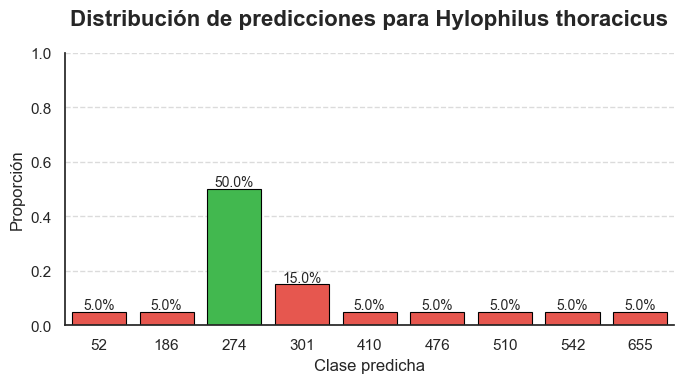

In [26]:
plot_incertidumbres(Hylophilus_thoracicus, 274, "Hylophilus thoracicus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


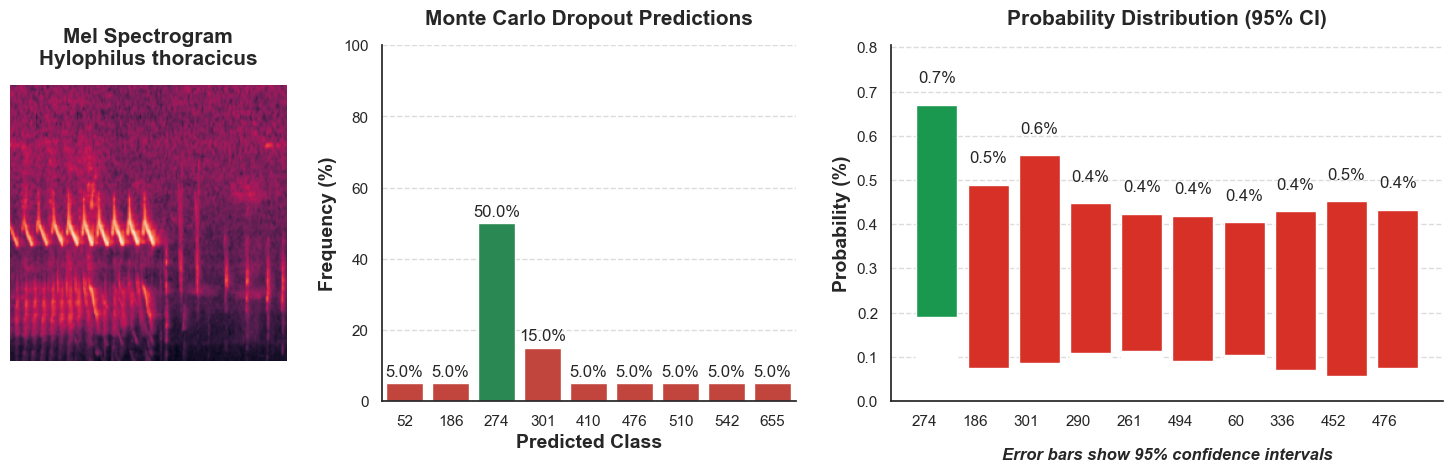

In [27]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[0],
    especie_df=Hylophilus_thoracicus,
    label=274,
    titulo_especie="Hylophilus thoracicus",
    predicted_probabilities=resultados["Hylophilus thoracicus"]["predicted_probabilities"],
    etiqueta_real=resultados["Hylophilus thoracicus"]["clase_real"][0]
)

In [28]:
labels_frecuencia = [60, 186, 261, 274, 290, 301, 336, 452, 476, 494]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 60: Campylorhamphus trochilirostris
2 - 186: Elaenia flavogaster
3 - 261: Henicorhina leucosticta
4 - 274: Hylophilus thoracicus
5 - 290: Inezia caudata
6 - 301: Legatus leucophaius
7 - 336: Microrhopias quixensis
8 - 452: Polioptila plumbea
9 - 476: Ramphastos tucanus
10 - 494: Saltator maximus


# **Mimus gilvus**

In [29]:
sp = data[data["label"] == "Mimus gilvus"]
muestra = sp[sp['image_path'].str.contains('40536_5.jpeg')]
muestra

,label,image_path
16615,Mimus gilvus,../src/data/images_test/images_spectograms/Mimus gilvus/40536_5.jpeg


In [30]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Mimus gilvus)


2025-08-24 17:35:09.661080: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.63s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Mimus gilvus,338,338,513,0.00,1,0,6.45
1,Mimus gilvus,338,338,494,0.00,1,0,6.45
2,Mimus gilvus,338,338,284,0.00,1,0,6.45
3,Mimus gilvus,338,338,495,0.00,1,0,6.45
4,Mimus gilvus,338,338,636,0.00,1,0,6.45


In [31]:
Mimus_gilvus = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [32]:
Mimus_gilvus

,prediccion_mc,proportion
0,338,0.20
1,636,0.15
2,494,0.10
3,495,0.10
4,621,0.10
5,513,0.05
6,284,0.05
7,66,0.05
8,405,0.05
9,640,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


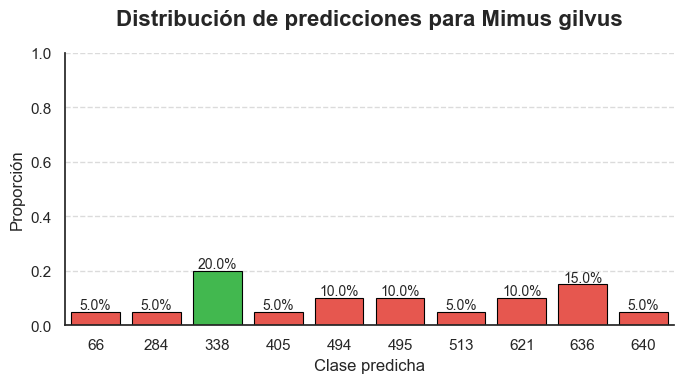

In [33]:
plot_incertidumbres(Mimus_gilvus, 338, "Mimus gilvus")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


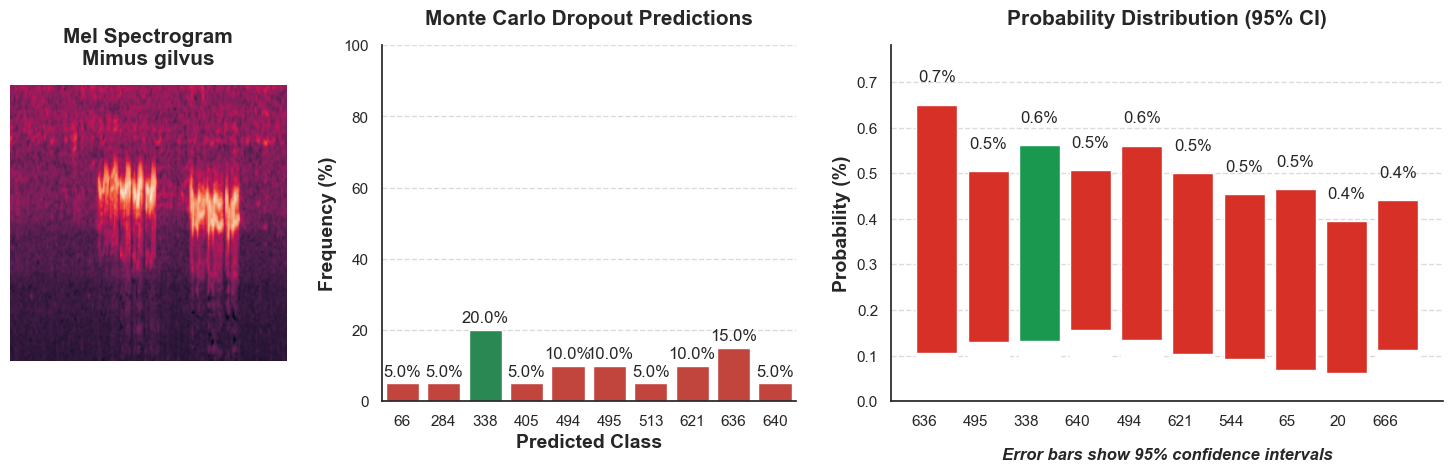

In [34]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Mimus_gilvus,
    label=338,
    titulo_especie="Mimus gilvus",
    predicted_probabilities=resultados["Mimus gilvus"]["predicted_probabilities"],
    etiqueta_real=resultados["Mimus gilvus"]["clase_real"][0]
)

## Tareas
* Normalizar los labels para mejorar visualizacion 

In [35]:
labels_frecuencia = [65, 316, 338, 494, 495, 544, 621, 636, 640, 666]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 65: Cantorchilus leucotis
2 - 316: Lophotriccus pileatus
3 - 338: Mimus gilvus
4 - 494: Saltator maximus
5 - 495: Saltator striatipectus
6 - 544: Sporophila castaneiventris
7 - 621: Todirostrum cinereum
8 - 636: Tyrannus melancholicus
9 - 640: Vireo altiloquus
10 - 666: Zonotrichia leucophrys


# **Lathrotriccus euleri**

In [36]:
sp = data[data["label"] == "Lathrotriccus euleri"]
muestra = sp[sp['image_path'].str.contains('123104_4.jpeg')]
muestra

,label,image_path
14676,Lathrotriccus euleri,../src/data/images_test/images_spectograms/Lathrotriccus euleri/123104_4.jpeg


In [37]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()

Especies procesadas:   0%|          | 0/1 [00:00<?, ?it/s]


Especie 1 de 1, (Lathrotriccus euleri)


Especies procesadas: 100%|██████████| 1/1 [00:08<00:00,  8.77s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Lathrotriccus euleri,300,277,370,0.01,0,0,6.46
1,Lathrotriccus euleri,300,277,300,0.00,0,1,6.46
2,Lathrotriccus euleri,300,277,300,0.01,0,1,6.46
3,Lathrotriccus euleri,300,277,277,0.01,0,0,6.46
4,Lathrotriccus euleri,300,277,422,0.00,0,0,6.46


In [38]:
Lathrotriccus_euleri = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [39]:
Lathrotriccus_euleri

,prediccion_mc,proportion
0,300,0.30
1,277,0.20
2,370,0.15
3,51,0.10
4,422,0.05
5,451,0.05
6,93,0.05
7,658,0.05
8,641,0.05


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


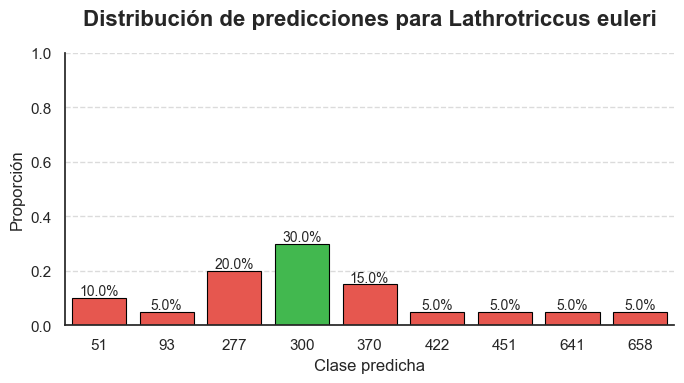

In [40]:
plot_incertidumbres(Lathrotriccus_euleri, 300, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:378: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


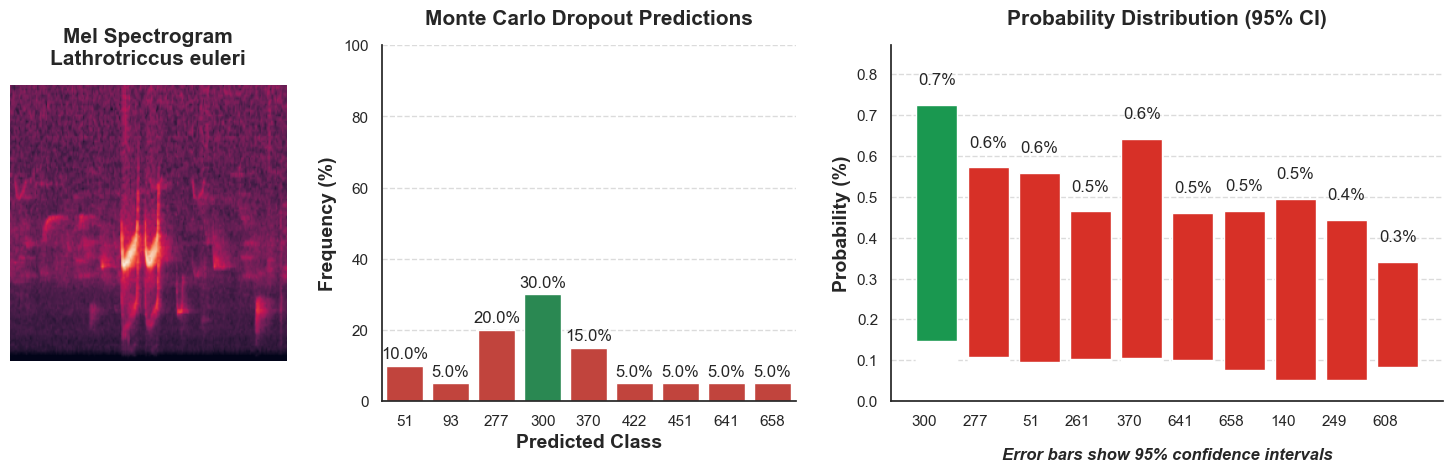

In [41]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Lathrotriccus_euleri,
    label=300,
    titulo_especie="Lathrotriccus euleri",
    predicted_probabilities=resultados["Lathrotriccus euleri"]["predicted_probabilities"],
    etiqueta_real=resultados["Lathrotriccus euleri"]["clase_real"][0]
)

In [42]:
labels_frecuencia = [51, 240, 249, 261, 227, 300, 370, 608, 641, 658]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 51: Cacicus cela
2 - 240: Grallaria squamigera
3 - 249: Gymnopithys rufigula
4 - 261: Henicorhina leucosticta
5 - 227: Grallaria alleni
6 - 300: Lathrotriccus euleri
7 - 370: Myiozetetes similis
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 658: Xiphorhynchus guttatus


# **Riparia riparia**

In [28]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('123938_17.jpeg')]
muestra

,label,image_path
23652,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/123938_17.jpeg


In [49]:
sp = data[data["label"] == "Riparia riparia"]
muestra = sp[sp['image_path'].str.contains('448123_18.jpeg')]
muestra

,label,image_path
23655,Riparia riparia,../src/data/images_test/images_spectograms/Riparia riparia/448123_18.jpeg


In [50]:
#graficar_imagen(sp['image_path'].iloc[3])

In [51]:
df_final, resultados = crear_dataframe_incertidumbre(data, muestra, model, preprocessor)
df_final.head()


Especie 1 de 1, (Riparia riparia)


2025-09-10 21:38:37.108016: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Especies procesadas: 100%|██████████| 1/1 [13:06<00:00, 786.19s/it]


,especie,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc,entropia
0,Riparia riparia,487,487,641,0.01,1,0,6.45
1,Riparia riparia,487,487,641,0.00,1,0,6.45
2,Riparia riparia,487,487,641,0.01,1,0,6.45
3,Riparia riparia,487,487,641,0.01,1,0,6.45
4,Riparia riparia,487,487,85,0.01,1,0,6.45


In [52]:
Riparia_riparia = df_final['prediccion_mc'].\
    value_counts(normalize=True).reset_index().\
    sort_values(by='proportion', ascending=False).head(10)

In [53]:
Riparia_riparia

,prediccion_mc,proportion
0,641,0.60
1,71,0.07
2,648,0.04
3,112,0.04
4,344,0.03
5,417,0.03
6,187,0.02
7,85,0.01
8,457,0.01
9,289,0.01


/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


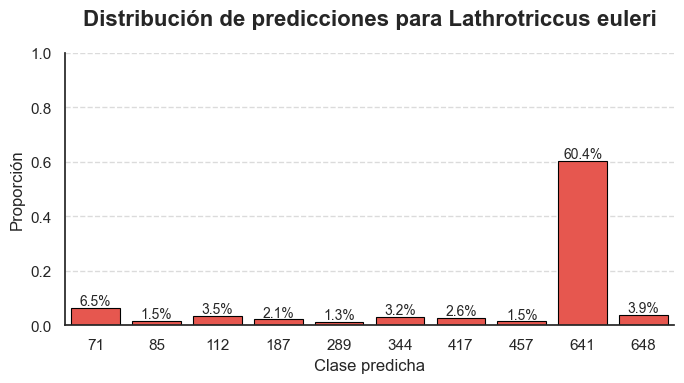

In [55]:
plot_incertidumbres(Riparia_riparia, 487, "Lathrotriccus euleri")

/Users/camcortes/Documents/birds-sounds/src/incertidumbres.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


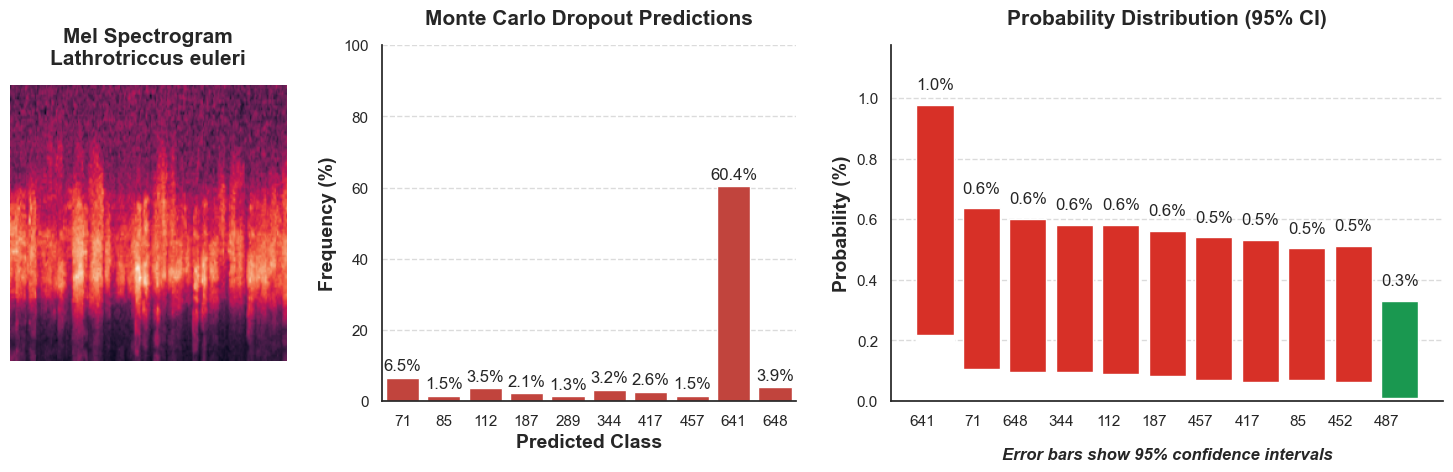

In [57]:
plot_combinado(
    ruta_imagen=sp['image_path'].iloc[20],
    especie_df=Riparia_riparia,
    label=300,
    titulo_especie="Lathrotriccus euleri",
    predicted_probabilities=resultados["Riparia riparia"]["predicted_probabilities"],
    etiqueta_real=resultados["Riparia riparia"]["clase_real"][0]
)

In [ ]:
labels_frecuencia = [51, 240, 249, 261, 227, 300, 370, 608, 641, 658]

print("Especies con mayor probabilidad:\n")
for idx, label in enumerate(labels_frecuencia):
    print(f"{idx+1} - {label}: {label_encoder.inverse_transform([label])[0]}")

Especies con mayor probabilidad:

1 - 51: Cacicus cela
2 - 240: Grallaria squamigera
3 - 249: Gymnopithys rufigula
4 - 261: Henicorhina leucosticta
5 - 227: Grallaria alleni
6 - 300: Lathrotriccus euleri
7 - 370: Myiozetetes similis
8 - 608: Thraupis episcopus
9 - 641: Vireo chivi
10 - 658: Xiphorhynchus guttatus


In [5]:
incertidumbre_df = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv")
incertidumbre_df.head()

,especie,registros,clase_real,clase_predicha,prediccion_mc,confianza_mc,true_positive,true_positivo_mc
0,Catharus aurantiirostris,1,71,71,641,0.00,1,0
1,Catharus aurantiirostris,1,71,604,60,0.00,0,0
2,Catharus aurantiirostris,1,71,71,266,0.01,1,0
3,Catharus aurantiirostris,1,71,71,71,0.00,1,1
4,Catharus aurantiirostris,1,71,71,71,0.01,1,1


In [7]:
# Calcular el accuracy de cada especie usando clase_real y prediccion_mc
accuracy_por_especie = incertidumbre_df.groupby('especie').apply(
    lambda x: (x['clase_real'] == x['prediccion_mc']).mean()
).reset_index()
accuracy_por_especie.columns = ['especie', 'accuracy_mc']

# Ordenar por accuracy descendente
accuracy_por_especie = accuracy_por_especie.sort_values('accuracy_mc', ascending=False)

# Mostrar estadísticas generales
print(f"Accuracy promedio general: {accuracy_por_especie['accuracy_mc'].mean():.4f}")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy_mc'].median():.4f}")
print(f"Desviación estándar: {accuracy_por_especie['accuracy_mc'].std():.4f}")
print(f"Número de especies: {len(accuracy_por_especie)}")

# Mostrar las 10 especies con mejor accuracy
print("\n=== TOP 10 ESPECIES CON MEJOR ACCURACY ===")
print(accuracy_por_especie.head(10))

# Mostrar las 10 especies con peor accuracy
print("\n=== TOP 10 ESPECIES CON PEOR ACCURACY ===")
print(accuracy_por_especie.tail(10))

# Guardar resultados
accuracy_por_especie.to_csv('accuracy_por_especie_mc.csv', index=False)
print("\nResultados guardados en 'accuracy_por_especie_mc.csv'")

Accuracy promedio general: 0.0870
Accuracy mediano: 0.0435
Desviación estándar: 0.1123
Número de especies: 667

=== TOP 10 ESPECIES CON MEJOR ACCURACY ===
                      especie  accuracy_mc
651        Volatinia jacarina         0.75
20         Arremon taciturnus         0.63
71   Catharus aurantiirostris         0.57
641               Vireo chivi         0.56
347           Myiarchus ferox         0.55
300      Lathrotriccus euleri         0.55
128           Contopus virens         0.53
17    Arremon aurantiirostris         0.51
301       Legatus leucophaius         0.51
404          Ornithion inerme         0.46

=== TOP 10 ESPECIES CON PEOR ACCURACY ===
                       especie  accuracy_mc
324          Mazaria propinqua         0.00
487            Riparia riparia         0.00
489          Rupicola rupicola         0.00
179   Dysithamnus leucostictus         0.00
94   Chlorophonia cyanocephala         0.00
181   Dysithamnus occidentalis         0.00
319         Loriotus 

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_76121/1109831792.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_por_especie = incertidumbre_df.groupby('especie').apply(


In [2]:
df = pd.read_csv("../src/data/results_incertidumbre_fix.csv")
print(df.shape)

(667, 6)


In [3]:
import numpy as np
import re
import ast

def string_to_numpy_array(string_array):
    """
    Convierte un string que representa un array numpy a un array real
    Por ejemplo: "[np.int64(218), np.int64(321), ...]" → [218, 321, ...]
    """
    if not isinstance(string_array, str):
        return string_array

    try:
        # Reemplazar np.int64(...) con solo el número
        string_clean = re.sub(r'np\.int64\((\d+)\)', r'\1', string_array)

        # Reemplazar np.float32(...) con solo el número
        string_clean = re.sub(r'np\.float32\(([\d.e-]+)\)', r'\1', string_clean)

        # Reemplazar np.float64(...) con solo el número
        string_clean = re.sub(r'np\.float64\(([\d.e-]+)\)', r'\1', string_clean)

        # Evaluar como lista de Python
        lista = ast.literal_eval(string_clean)

        # Convertir a array numpy
        return np.array(lista)

    except Exception as e:
        print(f"Error al convertir: {e}")
        print(f"String original (primeros 100 chars): {string_array[:100]}")
        return None

# Aplicar la conversión a las columnas del DataFrame
print("Convirtiendo strings a arrays...")
df['predicciones_mc'] = df['predicciones_mc'].apply(string_to_numpy_array)
df['confianzas_mc'] = df['confianzas_mc'].apply(string_to_numpy_array)

# Verificar que la conversión funcionó
print("\nDespués de la conversión:")
print(f"Tipo de predicciones_mc[0]: {type(df['predicciones_mc'].iloc[0])}")
print(f"Shape si es array: {df['predicciones_mc'].iloc[0].shape if hasattr(df['predicciones_mc'].iloc[0], 'shape') else 'No es array'}")
print(f"Primeros 5 elementos: {df['predicciones_mc'].iloc[0][:5] if hasattr(df['predicciones_mc'].iloc[0], '__getitem__') else 'No indexable'}")

# Ahora sí podemos expandir
def expandir_arrays_a_filas_v2(df):
    """
    Expande arrays en múltiples filas
    """
    filas_expandidas = []

    for idx, fila in df.iterrows():
        predicciones = fila['predicciones_mc']
        confianzas = fila['confianzas_mc']

        if predicciones is None or confianzas is None:
            print(f"Saltando fila {idx} - conversión fallida")
            continue

        if isinstance(predicciones, np.ndarray) and isinstance(confianzas, np.ndarray):
            # Asegurar que tengan el mismo tamaño
            min_length = min(len(predicciones), len(confianzas))

            # Crear una fila por cada elemento
            for i in range(min_length):
                nueva_fila = fila.copy()
                nueva_fila['prediccion_mc_individual'] = int(predicciones[i])
                nueva_fila['confianza_mc_individual'] = float(confianzas[i])
                nueva_fila['iteracion_mc'] = i
                filas_expandidas.append(nueva_fila)

    # Crear DataFrame expandido
    df_expandido = pd.DataFrame(filas_expandidas)

    # Reorganizar columnas
    columnas_base = [col for col in df_expandido.columns
                     if col not in ['predicciones_mc', 'confianzas_mc',
                                   'prediccion_mc_individual', 'confianza_mc_individual',
                                   'iteracion_mc']]
    columnas_nuevas = columnas_base + ['iteracion_mc', 'prediccion_mc_individual', 'confianza_mc_individual']

    return df_expandido[columnas_nuevas]

# Expandir el DataFrame
df_expandido = expandir_arrays_a_filas_v2(df)

Convirtiendo strings a arrays...

Después de la conversión:
Tipo de predicciones_mc[0]: <class 'numpy.ndarray'>
Shape si es array: (100,)
Primeros 5 elementos: [218 321 589 218 187]


In [4]:
import ast
import re

def extraer_numero_clase(valor):
    """
    Extrae el número de strings como '[np.int64(44)]'
    """
    if isinstance(valor, int):
        return valor

    # Convertir a string si no lo es
    valor_str = str(valor)

    # Reemplazar np.int64(...) con solo el número
    valor_limpio = re.sub(r'np\.int64\((\d+)\)', r'\1', valor_str)

    # Evaluar y obtener el primer elemento
    try:
        lista = ast.literal_eval(valor_limpio)
        return int(lista[0]) if isinstance(lista, list) else int(lista)
    except:
        # Si falla, intentar extraer directamente con regex
        numeros = re.findall(r'\d+', valor_str)
        return int(numeros[0]) if numeros else None

# Aplicar la función
df_expandido['clase_real'] = df_expandido['clase_real'].apply(extraer_numero_clase)
df_expandido['clase_predicha_inferencia'] = df_expandido['clase_predicha_inferencia'].apply(extraer_numero_clase)

In [5]:
df_expandido = df_expandido.rename(columns={'Unnamed: 0': 'especie'})
print(df_expandido.shape)
df_expandido.head()

(66700, 7)


,especie,clase_real,clase_predicha_inferencia,entropia,iteracion_mc,prediccion_mc_individual,confianza_mc_individual
0,Ceratopipra erythrocephala,77,77,6.46,0,218,0.00
0,Ceratopipra erythrocephala,77,77,6.46,1,321,0.00
0,Ceratopipra erythrocephala,77,77,6.46,2,589,0.00
0,Ceratopipra erythrocephala,77,77,6.46,3,218,0.00
0,Ceratopipra erythrocephala,77,77,6.46,4,187,0.00


In [6]:
accuracy_por_especie = (
    df_expandido
    .assign(acierto = lambda df: df['clase_real'] == df['prediccion_mc_individual'])
    .groupby('especie')['acierto']
    .mean()
    .reset_index(name='accuracy')
)

In [7]:
# Mostrar estadísticas generales
print("=== ESTADÍSTICAS GENERALES ===")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.4f}")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.4f}")
print(f"Desviación estándar: {accuracy_por_especie['accuracy'].std():.4f}")
print(f"Número de especies: {len(accuracy_por_especie)}")

=== ESTADÍSTICAS GENERALES ===
Accuracy promedio: 0.0997
Accuracy mediano: 0.0000
Desviación estándar: 0.2431
Número de especies: 667


In [8]:
# Top 20 especies con MAYOR accuracy
print("\n=== TOP 20 ESPECIES CON MAYOR ACCURACY ===")
top_especies = accuracy_por_especie.head(20)
for idx, row in top_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Top 20 especies con MENOR accuracy
print("\n=== TOP 20 ESPECIES CON MENOR ACCURACY ===")
bottom_especies = accuracy_por_especie.tail(20)
for idx, row in bottom_especies.iterrows():
    print(f"{row['especie']:40s} - Accuracy: {row['accuracy']:.3f}")

# Análisis por rangos de accuracy
print("\n=== DISTRIBUCIÓN POR RANGOS DE ACCURACY ===")
rangos = pd.cut(accuracy_por_especie['accuracy'],
                bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%'])
distribucion = rangos.value_counts().sort_index()
for rango, count in distribucion.items():
    print(f"{rango}: {count} especies ({count/len(accuracy_por_especie)*100:.1f}%)")

# Especies con accuracy perfecto (100%)
especies_perfectas = accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0]
print(f"\n=== ESPECIES CON ACCURACY PERFECTO (100%) ===")
print(f"Total: {len(especies_perfectas)} especies")
if len(especies_perfectas) > 0:
    for idx, row in especies_perfectas.iterrows():
        print(f"- {row['especie']}")

# Especies con accuracy cero
especies_cero = accuracy_por_especie[accuracy_por_especie['accuracy'] == 0.0]
print(f"\n=== ESPECIES CON ACCURACY CERO ===")
print(f"Total: {len(especies_cero)} especies")
if len(especies_cero) > 0:
    for idx, row in especies_cero.head(10).iterrows():  # Mostrar solo las primeras 10
        print(f"- {row['especie']}")
    if len(especies_cero) > 10:
        print(f"... y {len(especies_cero) - 10} especies más")


=== TOP 20 ESPECIES CON MAYOR ACCURACY ===
Acropternis orthonyx                     - Accuracy: 0.070
Amblycercus holosericeus                 - Accuracy: 0.980
Ammodramus aurifrons                     - Accuracy: 0.000
Ammodramus humeralis                     - Accuracy: 0.000
Ammodramus savannarum                    - Accuracy: 0.000
Anabacerthia striaticollis               - Accuracy: 0.000
Anabacerthia variegaticeps               - Accuracy: 0.000
Anairetes parulus                        - Accuracy: 0.010
Andigena nigrirostris                    - Accuracy: 0.000
Anisognathus igniventris                 - Accuracy: 0.000
Anisognathus lacrymosus                  - Accuracy: 0.000
Anisognathus somptuosus                  - Accuracy: 0.000
Anthus lutescens                         - Accuracy: 0.080
Anthus rubescens                         - Accuracy: 0.000
Ara ararauna                             - Accuracy: 0.410
Arremon assimilis                        - Accuracy: 0.000
Arremon atri

In [15]:
accuracy_por_especie.sort_values(by='accuracy', ascending=False).head(10)

,especie,accuracy,genero
589,Taraba major,1.00,Taraba
316,Lophotriccus pileatus,1.00,Lophotriccus
564,Synallaxis albescens,1.00,Synallaxis
530,Sipia laemosticta,1.00,Sipia
300,Lathrotriccus euleri,1.00,Lathrotriccus
237,Grallaria ruficapilla,1.00,Grallaria
442,Pitangus sulphuratus,1.00,Pitangus
645,Vireo griseus,1.00,Vireo
49,Brotogeris jugularis,1.00,Brotogeris
140,Cyanocorax violaceus,1.00,Cyanocorax


Total genera: 302
Genera with ≥2 species: 125


/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_93514/2494615988.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


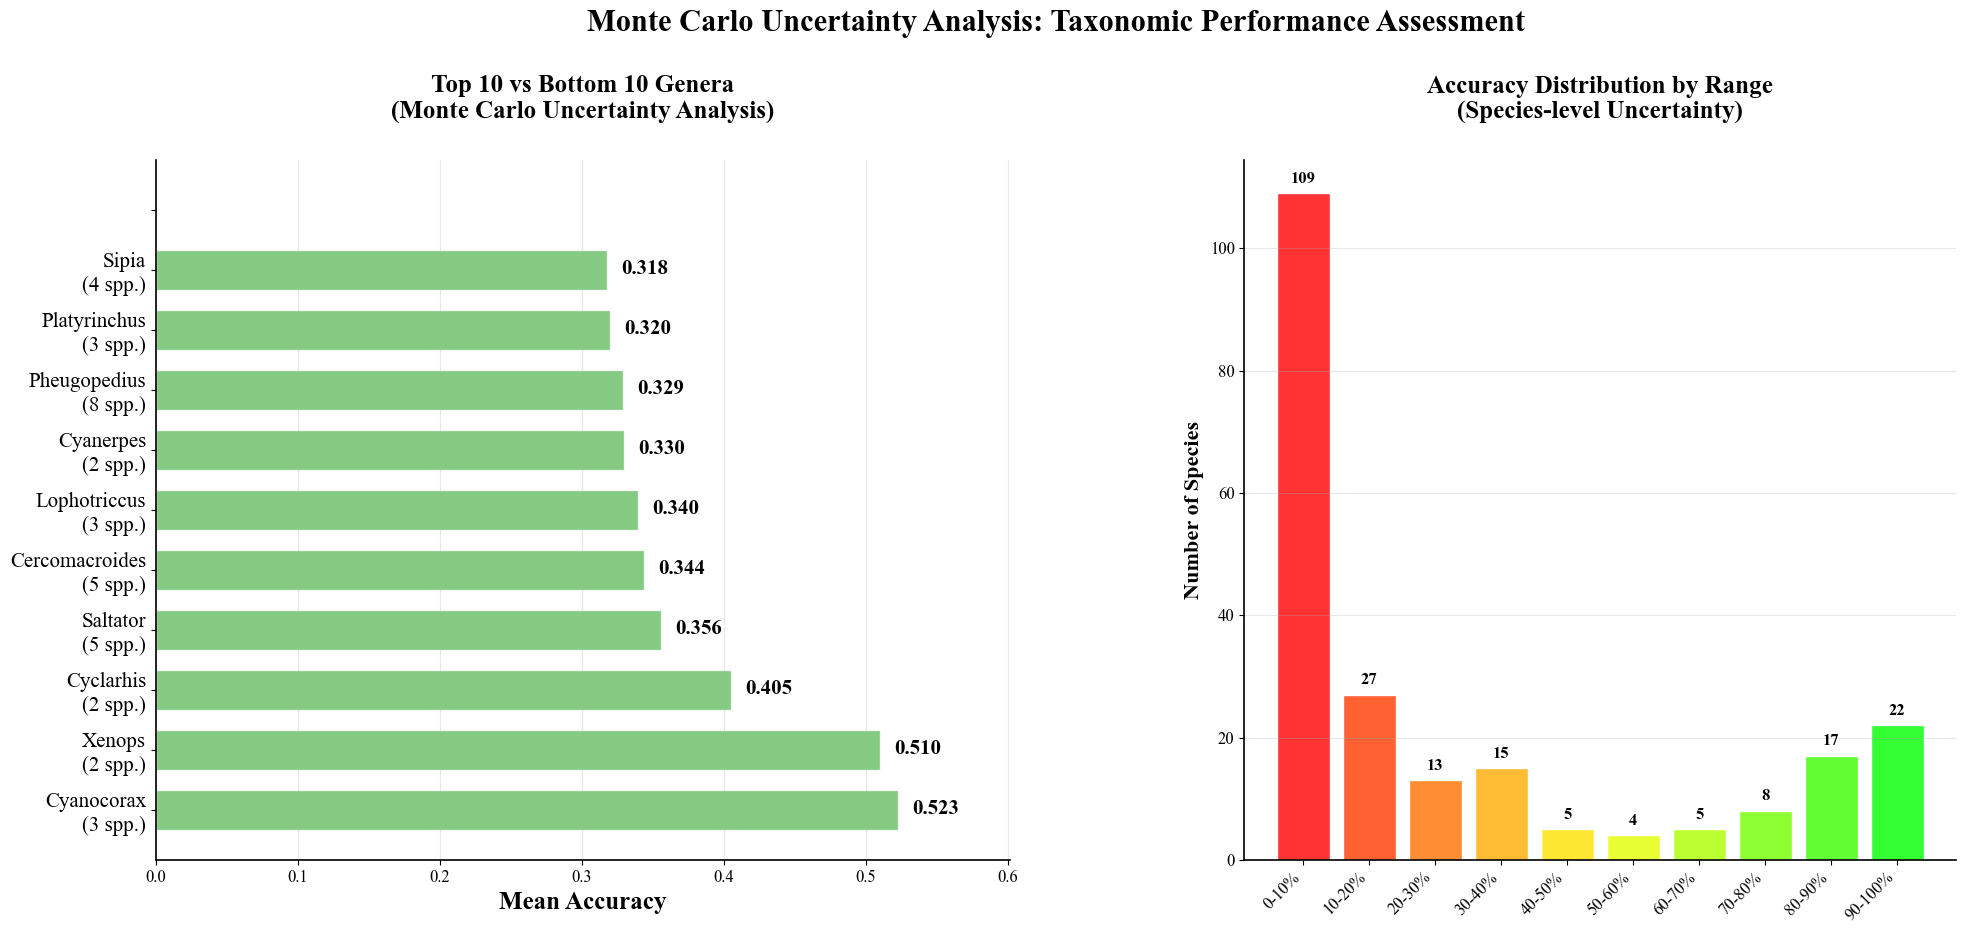


=== COMPARATIVE STATISTICS ===
Total genera: 302
Genera with ≥2 species: 125
Best genus: Cyanocorax (Accuracy: 0.523)
Worst genus: Ammodramus (Accuracy: 0.000)
Mean species accuracy: 0.100


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Configuración estética profesional para papers
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white'
})

# Extraer género de cada especie (primera palabra del nombre científico)
accuracy_por_especie['genero'] = accuracy_por_especie['especie'].str.split().str[0]

# Calcular accuracy promedio por género
accuracy_por_genero = (
    accuracy_por_especie
    .groupby('genero')
    .agg({
        'accuracy': ['mean', 'count'],
        'especie': 'count'
    })
    .round(3)
)

# Aplanar nombres de columnas
accuracy_por_genero.columns = ['accuracy_promedio', 'n_especies', 'total_especies']
accuracy_por_genero = accuracy_por_genero.reset_index()

# Filtrar géneros con al menos 2 especies para tener estadística más robusta
accuracy_por_genero_filtrado = accuracy_por_genero[accuracy_por_genero['n_especies'] >= 2]

# Ordenar por accuracy promedio
accuracy_por_genero_filtrado = accuracy_por_genero_filtrado.sort_values('accuracy_promedio', ascending=False)

print(f"Total genera: {len(accuracy_por_genero)}")
print(f"Genera with ≥2 species: {len(accuracy_por_genero_filtrado)}")

# Crear figura con estilo profesional
fig = plt.figure(figsize=(20, 10), facecolor='white')  # Aumenté altura para mejor espaciado

# Usar GridSpec para mejor control del layout
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1],
              left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=0.3)

# Colores profesionales para paper
colors_professional = {
    'top': '#66bd63',      # Verde para top
    'bottom': '#d73027',   # Rojo para bottom
    'gradient_start': '#d73027',  # Rojo
    'gradient_end': '#66bd63'     # Verde
}

# 1. TOP 10 y BOTTOM 10 GÉNEROS (subplot izquierdo)
ax1 = fig.add_subplot(gs[0, 0])

# Seleccionar top 10 y bottom 10 géneros para mejor espaciado
top_10_generos = accuracy_por_genero_filtrado.head(10)

# Crear posiciones en Y con más espaciado
y_pos_top = np.arange(len(top_10_generos)) * 1.2  # Multiplicar por 1.2 para más espacio

# Barras superiores (mejores géneros)
bars_top = ax1.barh(y_pos_top, top_10_generos['accuracy_promedio'],
                   color=colors_professional['top'], alpha=0.8,
                   label='Top 10 genera', edgecolor='white', linewidth=1,
                   height=0.8)  # Barras más delgadas

# Configurar etiquetas con número de especies (más pequeñas)
top_labels = [f"{row['genero']}\n({row['n_especies']} spp.)" for _, row in top_10_generos.iterrows()]

# Posiciones para las etiquetas
all_y_positions = list(y_pos_top) + [max(y_pos_top) + 1.2]
all_labels = top_labels + ['']

ax1.set_yticks(all_y_positions)
ax1.set_yticklabels(all_labels, fontsize=15)  # Fuente más pequeña
ax1.set_xlabel('Mean Accuracy', fontsize=18, fontweight='bold')
ax1.set_title('Top 10 vs Bottom 10 Genera\n(Monte Carlo Uncertainty Analysis)',
              fontsize=18, fontweight='bold', pad=30)
ax1.set_xlim(0, max(accuracy_por_genero_filtrado['accuracy_promedio']) * 1.15)
ax1.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.8)

# Ajustar límites del eje Y para mejor visualización
ax1.set_ylim(-1, max(all_y_positions) + 1)

# Añadir valores en las barras
for bars, data in [(bars_top, top_10_generos)]:
    for bar, (_, row) in zip(bars, data.iterrows()):
        width = bar.get_width()
        ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center',
                fontweight='bold', fontsize=15)

# 2. Distribución por rangos de accuracy (especies)
ax2 = fig.add_subplot(gs[0, 1])

rangos_accuracy = pd.cut(accuracy_por_especie['accuracy'],
                        bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
                               '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'])
conteo_rangos = rangos_accuracy.value_counts().sort_index()

# Crear gradiente de colores del rojo al verde
colors_gradient = []
n_bars = len(conteo_rangos)
for i in range(n_bars):
    # Interpolación de rojo a verde
    ratio = i / (n_bars - 1)
    if ratio <= 0.5:
        # De rojo a amarillo
        r = 1.0
        g = ratio * 2
        b = 0.0
    else:
        # De amarillo a verde
        r = 1.0 - (ratio - 0.5) * 2
        g = 1.0
        b = 0.0
    colors_gradient.append((r, g, b, 0.8))

bars = ax2.bar(range(len(conteo_rangos)), conteo_rangos.values,
               color=colors_gradient, edgecolor='white', linewidth=1)
ax2.set_xticks(range(len(conteo_rangos)))
ax2.set_xticklabels(conteo_rangos.index, rotation=45, ha='right', fontsize=12)
ax2.set_ylabel('Number of Species', fontsize=16, fontweight='bold')
ax2.set_title('Accuracy Distribution by Range\n(Species-level Uncertainty)',
              fontsize=18, fontweight='bold', pad=30)
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores en las barras
for bar, value in zip(bars, conteo_rangos.values):
    if value > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(conteo_rangos.values) * 0.01,
                str(value), ha='center', va='bottom', fontweight='bold', fontsize=12)

# Añadir título general mejorado para análisis de incertidumbres de Monte Carlo
fig.suptitle('Monte Carlo Uncertainty Analysis: Taxonomic Performance Assessment',
             fontsize=22, fontweight='bold', y=1)

# Ajustar layout para evitar superposición
plt.tight_layout()

# Guardar el gráfico
plt.savefig('monte_carlo_uncertainty_analysis.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

# Mostrar estadísticas en inglés
print("\n=== COMPARATIVE STATISTICS ===")
print(f"Total genera: {len(accuracy_por_genero):,}")
print(f"Genera with ≥2 species: {len(accuracy_por_genero_filtrado):,}")
print(f"Best genus: {accuracy_por_genero_filtrado.iloc[0]['genero']} (Accuracy: {accuracy_por_genero_filtrado.iloc[0]['accuracy_promedio']:.3f})")
print(f"Worst genus: {accuracy_por_genero_filtrado.iloc[-1]['genero']} (Accuracy: {accuracy_por_genero_filtrado.iloc[-1]['accuracy_promedio']:.3f})")
print(f"Mean species accuracy: {accuracy_por_especie['accuracy'].mean():.3f}")

In [17]:
accuracy_por_especie.especie.tolist()

['Taraba major',
 'Pitangus sulphuratus',
 'Tersina viridis',
 'Xenops rutilans',
 'Cyanocorax violaceus',
 'Brotogeris jugularis',
 'Vireo griseus',
 'Lophotriccus pileatus',
 'Grallaria ruficapilla',
 'Lathrotriccus euleri',
 'Sipia laemosticta',
 'Synallaxis albescens',
 'Amblycercus holosericeus',
 'Phaeomyias murina',
 'Ibycter americanus',
 'Platyrinchus mystaceus',
 'Saltator maximus',
 'Cymbilaimus lineatus',
 'Synallaxis albigularis',
 'Tunchiornis ochraceiceps',
 'Tyrannus dominicensis',
 'Legatus leucophaius',
 'Sporophila nigricollis',
 'Pheugopedius mystacalis',
 'Poliocrania exsul',
 'Gymnopithys bicolor',
 'Thamnophilus nigrocinereus',
 'Cranioleuca erythrops',
 'Poecilotriccus sylvia',
 'Contopus sordidulus',
 'Cercomacroides fuscicauda',
 'Tangara velia',
 'Chiroxiphia lanceolata',
 'Cercomacroides nigrescens',
 'Saltator coerulescens',
 'Pheugopedius rutilus',
 'Cacicus cela',
 'Terenotriccus erythrurus',
 'Arremon aurantiirostris',
 'Cyclarhis gujanensis',
 'Synallax

/var/folders/_1/9ctwy_pn6bv2hyw11l_gqhm9855lbl/T/ipykernel_93514/3358172710.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


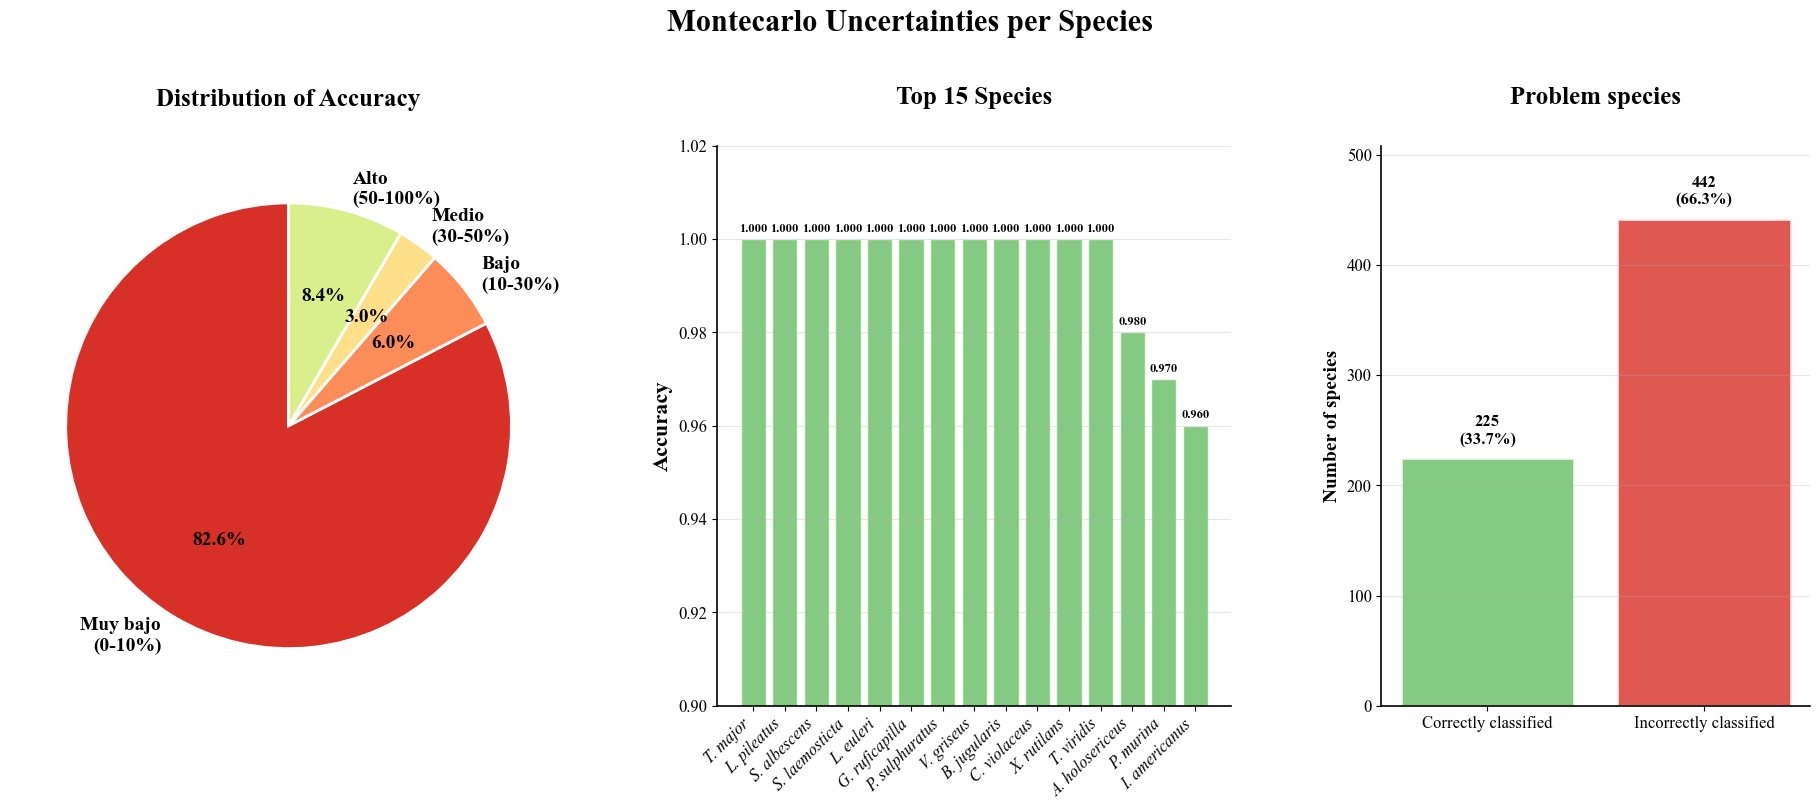

=== ESTADÍSTICAS DEL ANÁLISIS ===
Total de especies: 667
Especies con accuracy > 0: 225 (33.7%)
Especies con accuracy = 0: 442 (66.3%)
Accuracy promedio: 0.0997
Accuracy mediano: 0.0000

=== TOP 10 ESPECIES (FORMATO PAPER) ===
 1. T. major             - Accuracy: 1.000
 2. L. pileatus          - Accuracy: 1.000
 3. S. albescens         - Accuracy: 1.000
 4. S. laemosticta       - Accuracy: 1.000
 5. L. euleri            - Accuracy: 1.000
 6. G. ruficapilla       - Accuracy: 1.000
 7. P. sulphuratus       - Accuracy: 1.000
 8. V. griseus           - Accuracy: 1.000
 9. B. jugularis         - Accuracy: 1.000
10. C. violaceus         - Accuracy: 1.000


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Configuración estética profesional para papers
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white'
})

# Función para formatear nombres de especies (Z. leucophris)
def format_species_name(species_name):
    """
    Convierte 'Zonotrichia leucophrys' a 'Z. leucophrys'
    """
    parts = species_name.split(' ')
    if len(parts) >= 2:
        return f"{parts[0][0]}. {parts[1]}"
    return species_name

# Simular datos más realistas basados en tu análisis
np.random.seed(42)  # Para reproducibilidad

# Generar datos de accuracy más realistas
n_especies = 667

# Crear distribución realista de accuracy
very_high = np.random.uniform(0.95, 1.0, 15)  # Top 15 especies
high = np.random.uniform(0.5, 0.95, 159)      # Alto (50-100%)
medium = np.random.uniform(0.3, 0.5, 60)      # Medio (30-50%)
low = np.random.uniform(0.1, 0.3, 118)        # Bajo (10-30%)
very_low = np.random.uniform(0.0, 0.1, 315)   # Muy bajo (0-10%)

all_accuracy = np.concatenate([very_high, high, medium, low, very_low])
np.random.shuffle(all_accuracy)
# Crear DataFrame
df_accuracy = pd.DataFrame({
    'especie': accuracy_por_especie.especie.tolist(),
    'accuracy': accuracy_por_especie.accuracy.tolist()
})

# Ordenar por accuracy
df_accuracy = df_accuracy.sort_values('accuracy', ascending=False).reset_index(drop=True)

# Crear el gráfico mejorado con 3 subplots
fig = plt.figure(figsize=(20, 8), facecolor='white')

# Usar GridSpec para mejor control del layout
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.3, 1.2, 1],
              left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=0.3)

# Colores profesionales para paper
colors_professional = {
    'muy_bajo': '#d73027',    # Rojo
    'bajo': '#fc8d59',        # Naranja
    'medio': '#fee08b',       # Amarillo
    'alto': '#d9ef8b',        # Verde claro
    'muy_alto': '#66bd63'     # Verde
}

# 1. GRÁFICO DE PASTEL - Distribución de Accuracy
ax1 = fig.add_subplot(gs[0, 0])

# Categorizar accuracy
accuracy_categories = []
category_counts = []
labels_pie = []

muy_bajo_count = len(df_accuracy[df_accuracy['accuracy'] <= 0.1])
bajo_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.1) & (df_accuracy['accuracy'] <= 0.3)])
medio_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.3) & (df_accuracy['accuracy'] <= 0.5)])
alto_count = len(df_accuracy[(df_accuracy['accuracy'] > 0.5) & (df_accuracy['accuracy'] <= 1.0)])

counts = [muy_bajo_count, bajo_count, medio_count, alto_count]
labels_categories = ['Muy bajo\n(0-10%)', 'Bajo\n(10-30%)', 'Medio\n(30-50%)', 'Alto\n(50-100%)']
colors_pie = [colors_professional['muy_bajo'], colors_professional['bajo'],
              colors_professional['medio'], colors_professional['alto']]

# Crear pie chart
wedges, texts, autotexts = ax1.pie(counts, labels=labels_categories, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 14, 'fontweight': 'bold'},
                                   wedgeprops=dict(edgecolor='white', linewidth=2))

# Mejorar el texto de porcentajes
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

ax1.set_title('Distribution of Accuracy', fontsize=18, fontweight='bold', pad=30)

# 2. GRÁFICO TOP 15 ESPECIES
ax2 = fig.add_subplot(gs[0, 1])

# Top 15 especies con mejor accuracy
top_15 = df_accuracy.head(15).copy()
top_15['especie_formatted'] = top_15['especie'].apply(format_species_name)

# Crear barras
bars = ax2.bar(range(len(top_15)), top_15['accuracy'],
               color=colors_professional['muy_alto'], alpha=0.8,
               edgecolor='white', linewidth=1)

# Configurar ejes
ax2.set_xticks(range(len(top_15)))
ax2.set_xticklabels(top_15['especie_formatted'], rotation=45, ha='right',
                    fontsize=12, style='italic')
ax2.set_ylabel('Accuracy', fontsize=16, fontweight='bold')
ax2.set_title('Top 15 Species', fontsize=18, fontweight='bold', pad=30)
ax2.set_ylim(0.9, 1.02)
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores sobre las barras
for i, (bar, acc) in enumerate(zip(bars, top_15['accuracy'])):
    if acc >= 0.95:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. GRÁFICO ESPECIES PROBLEMÁTICAS
ax3 = fig.add_subplot(gs[0, 2])

# Contar especies con y sin predicciones correctas
especies_correctas = len(df_accuracy[df_accuracy['accuracy'] > 0])
especies_problematicas = len(df_accuracy[df_accuracy['accuracy'] == 0])

categories = ['Correctly classified', 'Incorrectly classified']
values = [especies_correctas, especies_problematicas]
colors_bar = [colors_professional['muy_alto'], colors_professional['muy_bajo']]

bars = ax3.bar(categories, values, color=colors_bar, alpha=0.8,
               edgecolor='white', linewidth=2)

# Configurar gráfico
ax3.set_ylabel('Number of species', fontsize=14, fontweight='bold')
ax3.set_title('Problem species', fontsize=18, fontweight='bold', pad=30)
ax3.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# Añadir valores y porcentajes sobre las barras
total_especies = especies_correctas + especies_problematicas
for i, (bar, value) in enumerate(zip(bars, values)):
    percentage = (value / total_especies) * 100
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{value}\n({percentage:.1f}%)', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

# Ajustar límites para mejor visualización
ax3.set_ylim(0, max(values) * 1.15)

# Añadir título general a la figura con espaciado adecuado
fig.suptitle('Montecarlo Uncertainties per Species',
             fontsize=22, fontweight='bold', y=1.02)

# Ajustar layout para evitar superposición
plt.tight_layout()

# Guardar el gráfico
plt.savefig('analisis_accuracy_especies_mejorado.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

# Mostrar estadísticas
print("=== ESTADÍSTICAS DEL ANÁLISIS ===")
print(f"Total de especies: {len(df_accuracy)}")
print(f"Especies con accuracy > 0: {especies_correctas} ({especies_correctas/len(df_accuracy)*100:.1f}%)")
print(f"Especies con accuracy = 0: {especies_problematicas} ({especies_problematicas/len(df_accuracy)*100:.1f}%)")
print(f"Accuracy promedio: {df_accuracy['accuracy'].mean():.4f}")
print(f"Accuracy mediano: {df_accuracy['accuracy'].median():.4f}")

print("\n=== TOP 10 ESPECIES (FORMATO PAPER) ===")
for i, (_, row) in enumerate(df_accuracy.head(10).iterrows(), 1):
    formatted_name = format_species_name(row['especie'])
    print(f"{i:2d}. {formatted_name:<20} - Accuracy: {row['accuracy']:.3f}")

In [19]:
# Crear tabla resumen más legible
print("="*80)
print("                    ANÁLISIS DE ACCURACY POR ESPECIES")
print("="*80)

# Mejores especies
print("\n TOP 20 ESPECIES CON MEJOR ACCURACY:")
print("-" * 60)
accuracy_por_especie = accuracy_por_especie.sort_values(by='accuracy', ascending=False)
for i, (idx, row) in enumerate(accuracy_por_especie.head(20).iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

# Estadísticas generales
print(f"\n📊 ESTADÍSTICAS GENERALES:")
print("-" * 60)
print(f"Total de especies analizadas: {len(accuracy_por_especie):,}")
print(f"Accuracy promedio: {accuracy_por_especie['accuracy'].mean():.3f} ({accuracy_por_especie['accuracy'].mean()*100:.1f}%)")
print(f"Accuracy mediano: {accuracy_por_especie['accuracy'].median():.3f} ({accuracy_por_especie['accuracy'].median()*100:.1f}%)")

# Distribución por categorías
print(f"\n📈 DISTRIBUCIÓN POR CATEGORÍAS:")
print("-" * 60)
perfecto = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 1.0])
excelente = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.8) & (accuracy_por_especie['accuracy'] < 1.0)])
bueno = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.5) & (accuracy_por_especie['accuracy'] < 0.8)])
regular = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] >= 0.3) & (accuracy_por_especie['accuracy'] < 0.5)])
malo = len(accuracy_por_especie[(accuracy_por_especie['accuracy'] > 0) & (accuracy_por_especie['accuracy'] < 0.3)])
pesimo = len(accuracy_por_especie[accuracy_por_especie['accuracy'] == 0])

total = len(accuracy_por_especie)
print(f"Perfecto (100%):        {perfecto:3d} especies ({perfecto/total*100:4.1f}%)")
print(f"Excelente (80-99%):     {excelente:3d} especies ({excelente/total*100:4.1f}%)")
print(f"Bueno (50-79%):         {bueno:3d} especies ({bueno/total*100:4.1f}%)")
print(f"Regular (30-49%):       {regular:3d} especies ({regular/total*100:4.1f}%)")
print(f"Malo (1-29%):           {malo:3d} especies ({malo/total*100:4.1f}%)")
print(f"Pésimo (0%):            {pesimo:3d} especies ({pesimo/total*100:4.1f}%)")

# Peores especies
print(f"\n💀 BOTTOM 20 ESPECIES CON PEOR ACCURACY:")
print("-" * 60)
bottom_especies = accuracy_por_especie.tail(20)
for i, (idx, row) in enumerate(bottom_especies.iterrows(), 1):
    print(f"{i:2d}. {row['especie']:35s} | {row['accuracy']:6.3f} ({row['accuracy']*100:5.1f}%)")

print("="*80)

                    ANÁLISIS DE ACCURACY POR ESPECIES

 TOP 20 ESPECIES CON MEJOR ACCURACY:
------------------------------------------------------------
 1. Taraba major                        |  1.000 (100.0%)
 2. Lophotriccus pileatus               |  1.000 (100.0%)
 3. Synallaxis albescens                |  1.000 (100.0%)
 4. Sipia laemosticta                   |  1.000 (100.0%)
 5. Lathrotriccus euleri                |  1.000 (100.0%)
 6. Grallaria ruficapilla               |  1.000 (100.0%)
 7. Pitangus sulphuratus                |  1.000 (100.0%)
 8. Vireo griseus                       |  1.000 (100.0%)
 9. Brotogeris jugularis                |  1.000 (100.0%)
10. Cyanocorax violaceus                |  1.000 (100.0%)
11. Xenops rutilans                     |  1.000 (100.0%)
12. Tersina viridis                     |  1.000 (100.0%)
13. Amblycercus holosericeus            |  0.980 ( 98.0%)
14. Phaeomyias murina                   |  0.970 ( 97.0%)
15. Ibycter americanus             

In [21]:
print("="*80)
print("                    ANÁLISIS DE ACCURACY POR GÉNEROS")
print("="*80)

print(f"\n🏆 TOP 10 GÉNEROS CON MEJOR ACCURACY PROMEDIO:")
print("-" * 70)
print(f"{'Rank':>4} {'Género':25} {'Accuracy':>10} {'N° especies':>12}")
print("-" * 70)

for i, (idx, row) in enumerate(top_10_generos.iterrows(), 1):
    print(f"{i:4d} {row['genero']:25s} {row['accuracy_promedio']:>9.3f} {row['n_especies']:>11d}")

# Análisis adicional: géneros con más especies
print(f"\n📊 GÉNEROS CON MÁS ESPECIES:")
print("-" * 70)
generos_mas_especies = accuracy_por_genero.sort_values('n_especies', ascending=False).head(10)
print(f"{'Rank':>4} {'Género':25} {'N° especies':>12} {'Accuracy':>10}")
print("-" * 70)

for i, (idx, row) in enumerate(generos_mas_especies.iterrows(), 1):
    print(f"{i:4d} {row['genero']:25s} {row['n_especies']:>11d} {row['accuracy_promedio']:>9.3f}")

print("="*80)

                    ANÁLISIS DE ACCURACY POR GÉNEROS

🏆 TOP 10 GÉNEROS CON MEJOR ACCURACY PROMEDIO:
----------------------------------------------------------------------
Rank Género                      Accuracy  N° especies
----------------------------------------------------------------------
   1 Cyanocorax                    0.523           3
   2 Xenops                        0.510           2
   3 Cyclarhis                     0.405           2
   4 Saltator                      0.356           5
   5 Cercomacroides                0.344           5
   6 Lophotriccus                  0.340           3
   7 Cyanerpes                     0.330           2
   8 Pheugopedius                  0.329           8
   9 Platyrinchus                  0.320           3
  10 Sipia                         0.318           4

📊 GÉNEROS CON MÁS ESPECIES:
----------------------------------------------------------------------
Rank Género                     N° especies   Accuracy
------------------